In [8]:
import pandas as pd

In [9]:
dados = pd.read_csv('/content/dados_estudantes.csv')
dados.head()

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado


In [10]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

In [11]:
dados['Estado civil'].value_counts(normalize = True)*100

,proportion
Estado civil,
Solteiro,88.584991
Casado,8.566908
Divorciado,2.056962
União Estável,0.565099
Legalmente Separado,0.135624
Viúvo,0.090416


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

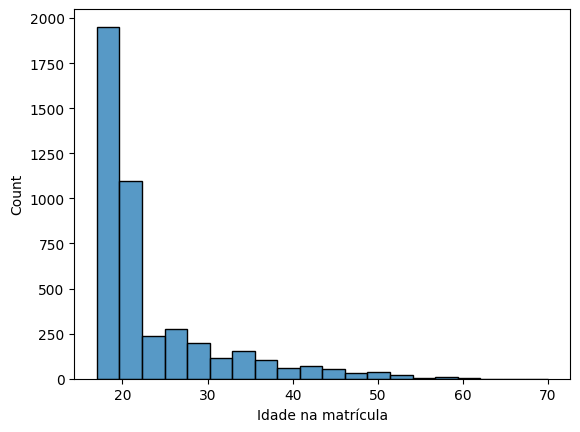

In [13]:
sns.histplot(dados,x = 'Idade na matrícula', bins = 20 );

In [14]:
destincao_cor = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'}
sns.set_palette(list(destincao_cor.values()))

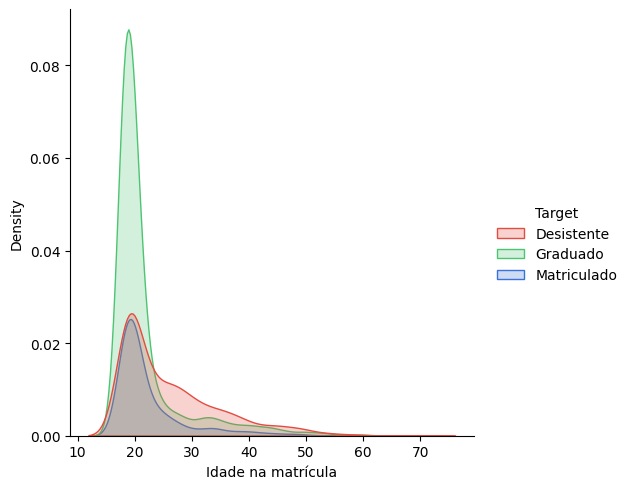

In [15]:
sns.displot(dados, x = 'Idade na matrícula', hue = 'Target', kind ='kde', fill = True);

In [16]:
dados['Estrangeiro'].value_counts(normalize = True)*100

,proportion
Estrangeiro,
Não,97.513562
Sim,2.486438


In [17]:
dados['Sexo'].value_counts(normalize = True)*100

,proportion
Sexo,
Feminino,64.82821
Masculino,35.17179


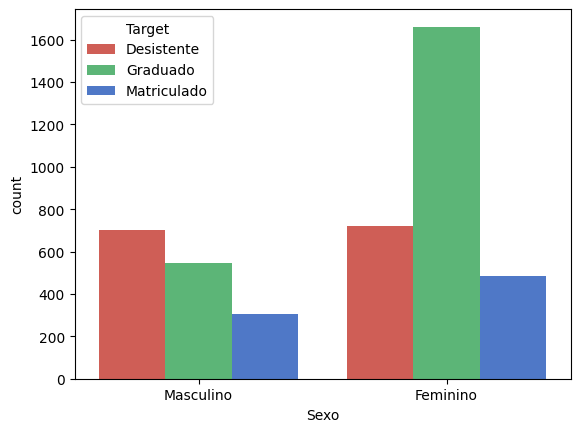

In [18]:
sns.countplot(data = dados, x = 'Sexo', hue = 'Target');

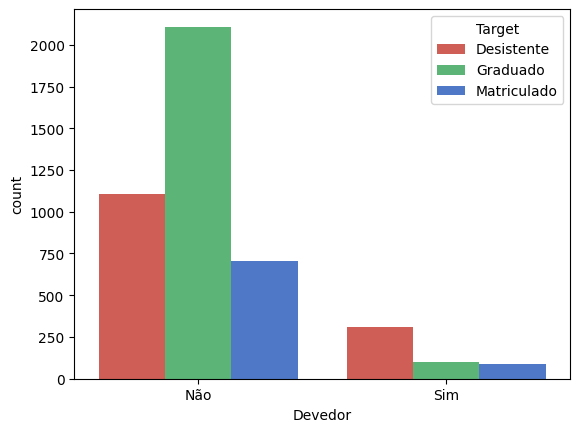

In [19]:
sns.countplot(data = dados, x = 'Devedor', hue = 'Target');

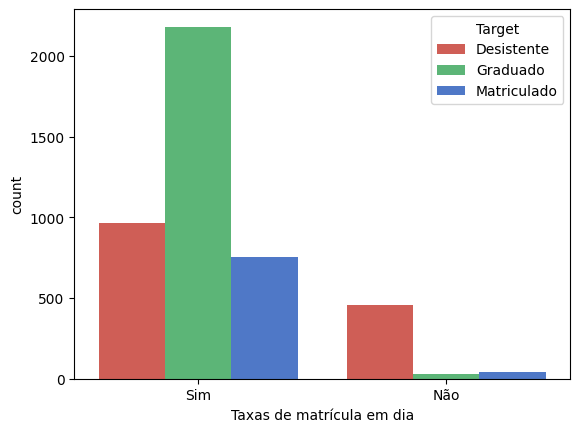

In [20]:
sns.countplot(data = dados, x = 'Taxas de matrícula em dia', hue = 'Target');

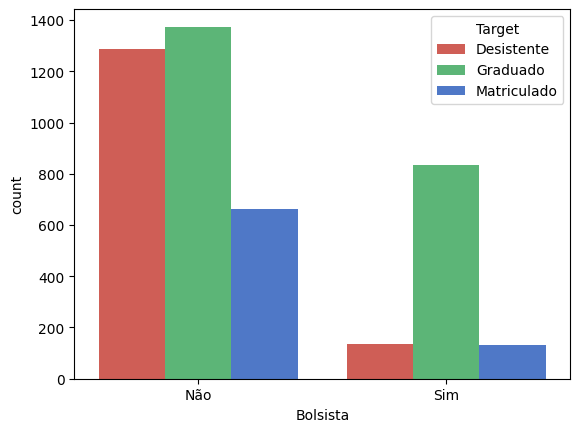

In [21]:
sns.countplot(data = dados, x = 'Bolsista', hue = 'Target');

In [22]:
import plotly.express as px

In [23]:
contagem = dados.groupby(['Curso','Target']).size().reset_index(name='Contagem')

contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x:(x/x.sum())*100)

fig = px.bar(contagem, y = 'Curso' , x = 'Porcentagem', color = 'Target', orientation = 'h',
             color_discrete_map =  {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'} );

fig.show()


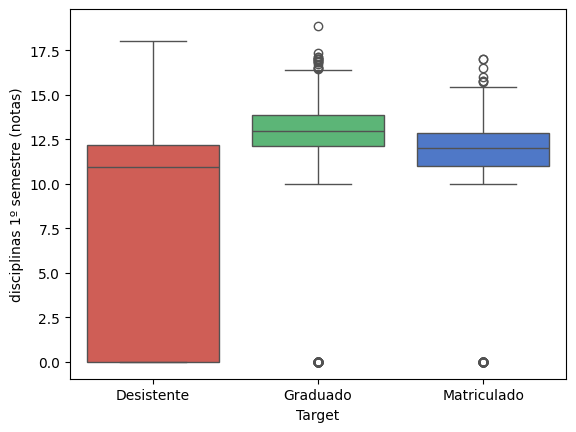

In [24]:
sns.boxplot(x = 'Target',y= 'disciplinas 1º semestre (notas)', data= dados, hue = 'Target');

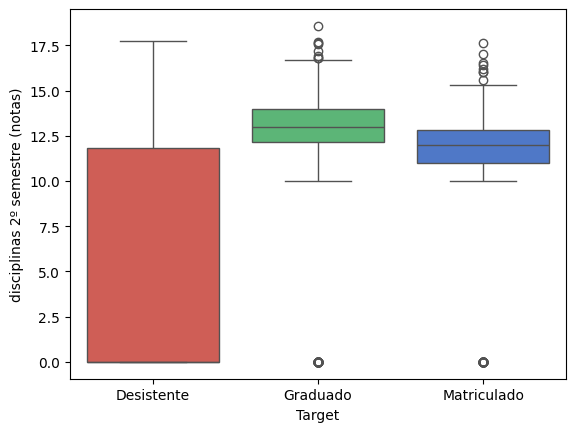

In [25]:
sns.boxplot(x = 'Target',y= 'disciplinas 2º semestre (notas)', data= dados, hue = 'Target');

In [26]:
dados['Target'].value_counts(normalize = True)*100

,proportion
Target,
Graduado,49.932188
Desistente,32.120253
Matriculado,17.947559


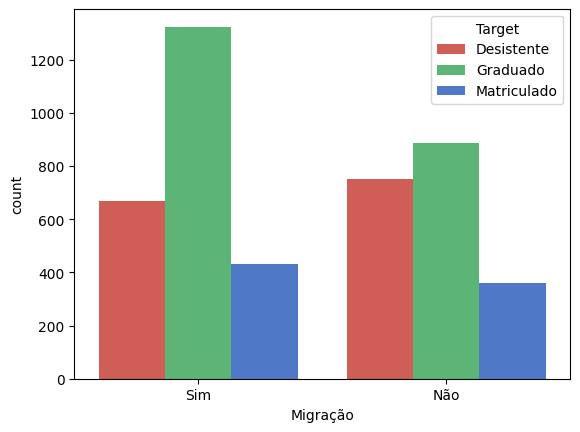

In [27]:
sns.countplot(dados,x = 'Migração', hue = 'Target' );

In [28]:
dados['Necessidades educacionais especiais'].value_counts(normalize = True)*100

,proportion
Necessidades educacionais especiais,
Não,98.847197
Sim,1.152803


In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

In [31]:
colunas_categoricas = ['Migração', 'Sexo','Estrangeiro', 'Necessidades educacionais especiais', 'Devedor',
                     'Taxas de matrícula em dia', 'Bolsista', 'Período','Estado civil', 'Curso', 'Qualificação prévia']

In [32]:
encoder = OneHotEncoder(drop = 'if_binary')

df_categorico = dados[colunas_categoricas]

df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico).toarray(),
                                                columns = encoder.get_feature_names_out(colunas_categoricas))

df_final = pd.concat([dados.drop(colunas_categoricas, axis = 1), df_encoded], axis = 1)

In [33]:
df_final

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),...,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
y = df_final['Target']
x = df_final.drop('Target', axis = 1)

In [40]:
from sklearn.model_selection import train_test_split

In [46]:
x, x_teste,y,y_teste = train_test_split(x,y,test_size = 0.15,stratify = y, random_state=0)
x_treino, x_val,y_treino,y_val = train_test_split(x,y, stratify= y, random_state=0)

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
#defiinindo parametros
modelo = RandomForestClassifier(random_state =0, max_depth = 10)
#treinando os dados que foram separados para treino
modelo.fit(x_treino,y_treino)
#utilzando o modelo treinado para fazer a previsão do meus dados separados para validação
y_predict = modelo.predict(x_val)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo.score(x_val, y_val)}')

Acurácia de treino: 0.9179664933564413
Acurácia de validação: 0.7538994800693241


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [51]:
matriz_confusao = confusion_matrix(y_val, y_predict)
matriz_confusao

array([[144,  32,   9],
       [ 14, 264,  10],
       [ 26,  51,  27]])

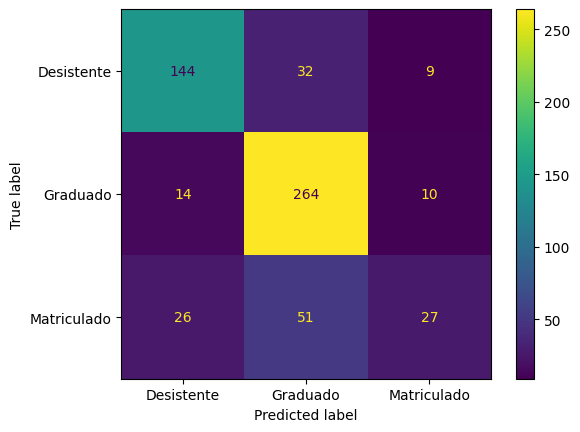

In [58]:
viz = ConfusionMatrixDisplay(confusion_matrix= matriz_confusao, display_labels= modelo.classes_)
viz.plot();

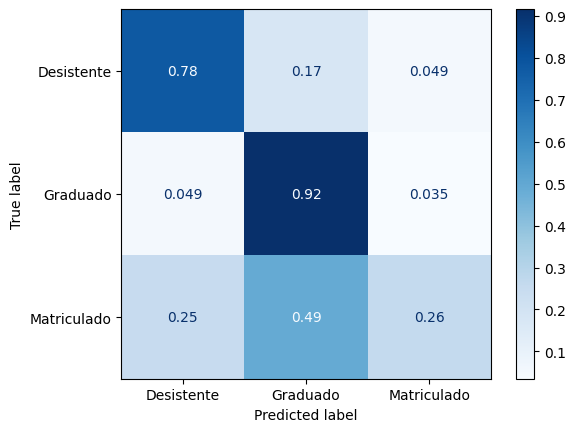

In [71]:
ConfusionMatrixDisplay.from_predictions(y_val, y_predict, normalize='true', cmap='Blues');


In [72]:
from sklearn.metrics import classification_report

In [73]:
#é possivel notar o desbalancemento no matriculado
print(classification_report(y_val,y_predict))

              precision    recall  f1-score   support

  Desistente       0.78      0.78      0.78       185
    Graduado       0.76      0.92      0.83       288
 Matriculado       0.59      0.26      0.36       104

    accuracy                           0.75       577
   macro avg       0.71      0.65      0.66       577
weighted avg       0.74      0.75      0.73       577



In [74]:
y_treino.value_counts()

,count
Target,
Graduado,863
Desistente,557
Matriculado,311


In [75]:
from imblearn.over_sampling import SMOTE

In [78]:
oversample = SMOTE(random_state = 0)
x_balanceado,y_balanceado = oversample.fit_resample(x_treino, y_treino)

In [79]:
y_balanceado.value_counts()

,count
Target,
Desistente,863
Graduado,863
Matriculado,863


In [81]:
modelo = RandomForestClassifier(random_state=0, max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_pred = modelo.predict(x_val)

              precision    recall  f1-score   support

  Desistente       0.82      0.72      0.77       185
    Graduado       0.81      0.87      0.84       288
 Matriculado       0.50      0.51      0.51       104

    accuracy                           0.76       577
   macro avg       0.71      0.70      0.70       577
weighted avg       0.76      0.76      0.75       577



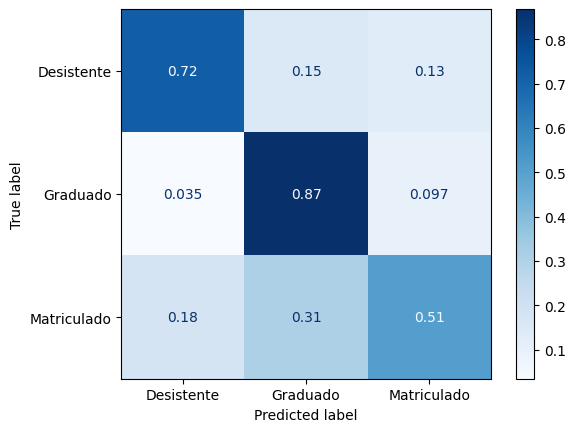

In [88]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues')

In [91]:
from imblearn.pipeline import Pipeline as imbpipeline

In [92]:
modelo = RandomForestClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample',SMOTE()),('floresta',modelo)])


In [94]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [99]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall_weighted')
cv_resultados['test_score']

array([0.75108225, 0.78354978, 0.75974026, 0.7527115 , 0.75921909])

In [102]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'intervalo de confiança: [{media - 2 * desvio_padrao}, {min(media + 2 * desvio_padrao, 1.0)}]')

intervalo de confiança: [0.7379372339114288, 0.7845839181108077]


              precision    recall  f1-score   support

  Desistente       0.84      0.69      0.76       131
    Graduado       0.81      0.88      0.84       204
 Matriculado       0.46      0.51      0.48        73

    accuracy                           0.75       408
   macro avg       0.71      0.69      0.70       408
weighted avg       0.76      0.75      0.75       408



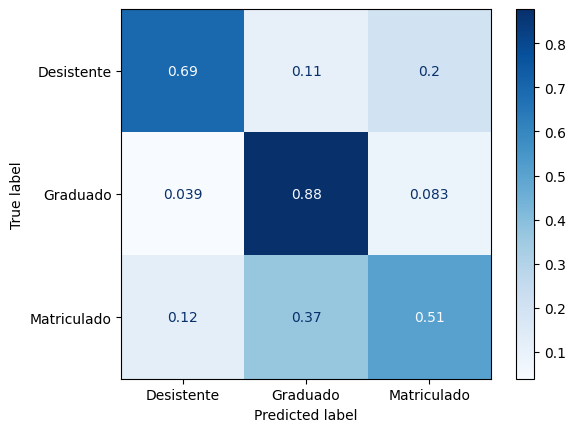

In [108]:
oversample = SMOTE(random_state= 0)
x_balanceado, y_balanceado = oversample.fit_resample(x,y)
modelo = RandomForestClassifier(random_state = 0 , max_depth = 10)
modelo.fit(x_balanceado, y_balanceado)
y_predict = modelo.predict(x_teste)

print(classification_report(y_teste, y_predict))
ConfusionMatrixDisplay.from_predictions(y_teste, y_predict, normalize='true', cmap='Blues');